# Sales Performance Dashboard using Python

## Project Introduction

This project presents a Sales Performance Dashboard created using Python for data analysis and visualization. The analysis is based on the Superstore sales dataset and focuses on understanding business performance through revenue trends, product sales, regional analysis, category distribution, and profit trends.

The project uses Python libraries such as Pandas, Matplotlib, and Seaborn to clean, analyze, and visualize the data. The dashboard helps identify important business insights that can support strategic decision-making and sales improvement.

## Import Libraries

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

## Load Dataset

In [5]:
df = pd.read_csv("Sample - Superstore.csv", encoding='latin1')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Dataset Overview

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

## Data Cleaning and Date Preprocessing

The date columns were converted into datetime format to enable time-series analysis and monthly sales trend visualization.

In [8]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

df['Month_Year'] = df['Order Date'].dt.to_period('M')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Month_Year
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016-11
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016-11
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016-06
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015-10
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015-10


## Monthly Revenue Trend

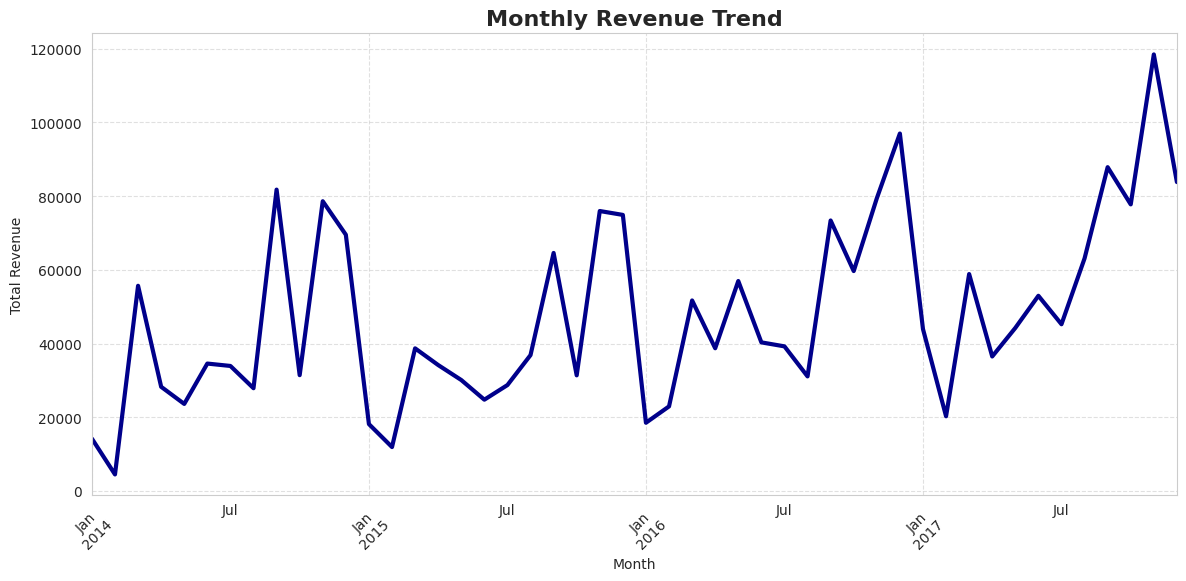

In [9]:
monthly_sales = df.groupby('Month_Year')['Sales'].sum()

plt.figure(figsize=(14,6))

monthly_sales.plot(
    color='darkblue',
    linewidth=3
)

plt.title(
    'Monthly Revenue Trend',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Month')
plt.ylabel('Total Revenue')

plt.xticks(rotation=45)

plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

#### Insights
- Revenue increased over time.
- Some months show higher sales peaks, indicating seasonal demand.
- The company experienced fluctuations in monthly performance.

### Top 10 Best-Selling Products

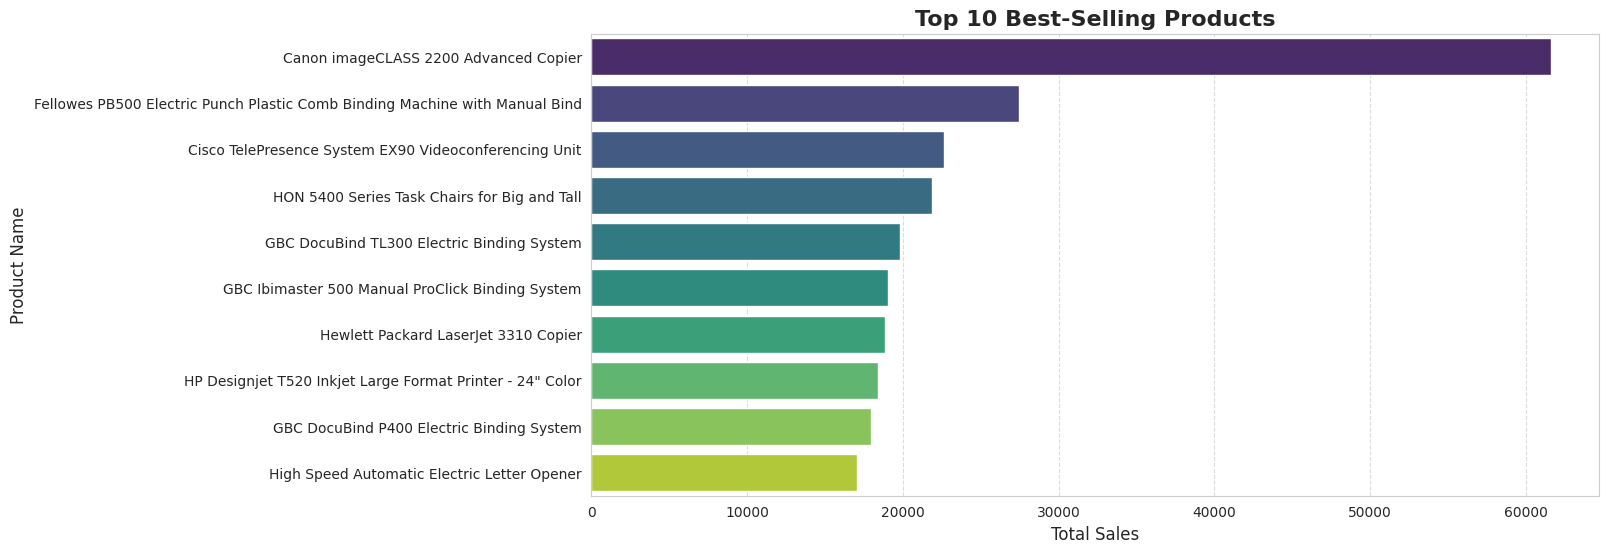

In [10]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(13,6))

sns.barplot(
    x=top_products.values,
    y=top_products.index,
    hue=top_products.index,
    palette='viridis',
    legend=False
)

plt.title(
    'Top 10 Best-Selling Products',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel(
    'Total Sales',
    fontsize=12
)

plt.ylabel(
    'Product Name',
    fontsize=12
)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

#### Insights
- Canon imageCLASS 2200 Advanced Copier generated the highest sales revenue.
- Technology and office equipment products dominate the top-selling list.
- A small number of products contribute significantly to overall revenue.

### Regional Sales Performance

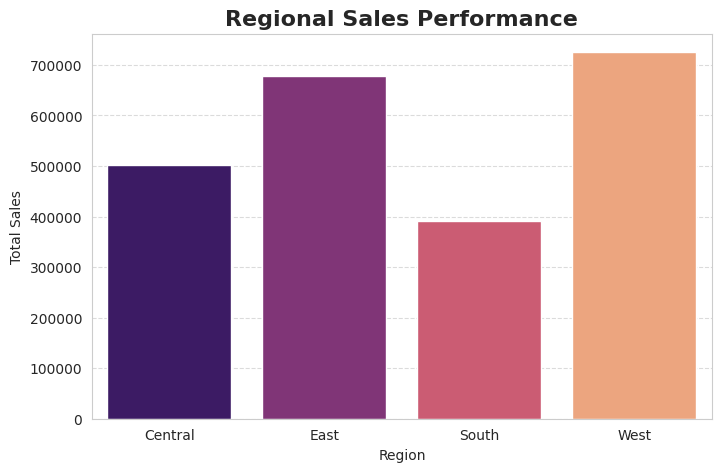

In [12]:
regional_sales = df.groupby('Region')['Sales'].sum()

plt.figure(figsize=(8,5))

sns.barplot(
    x=regional_sales.index,
    y=regional_sales.values,
    hue=regional_sales.index,
    palette='magma',
    legend=False
)

plt.title(
    'Regional Sales Performance',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Region')
plt.ylabel('Total Sales')

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

#### Insights
- The West region achieved the highest overall sales performance.
- Sales vary across regions, indicating differences in market demand.
- Some regions may require improved sales strategies to increase performance.

### Sales Distribution by Category

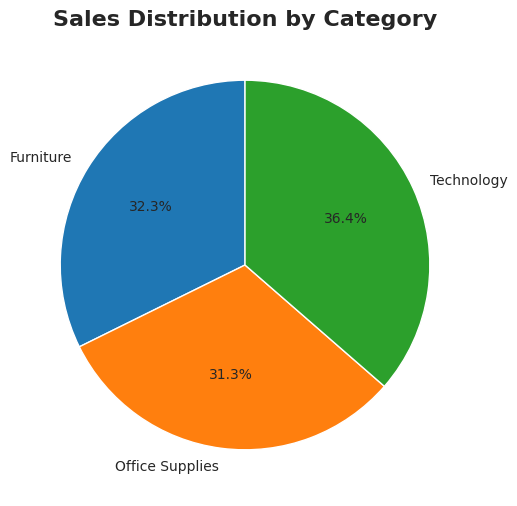

In [ ]:
category_sales = df.groupby('Category')['Sales'].sum()

plt.figure(figsize=(8,6))

plt.pie(
    category_sales,
    labels=category_sales.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title(
    'Sales Distribution by Category',
    fontsize=16,
    fontweight='bold'
)

plt.show()

#### Insights
- Technology contributes the largest share of total sales.
- Furniture and Office Supplies also represent important business segments.
- Category-level analysis helps identify the strongest revenue-generating areas.

### Monthly Profit Trend

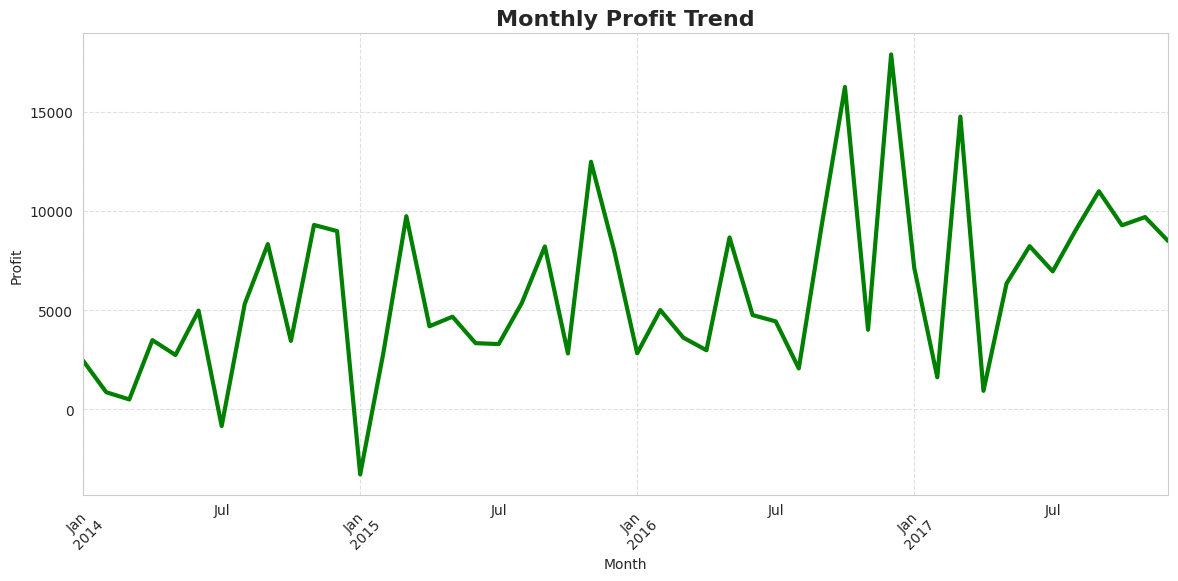

In [ ]:
monthly_profit = df.groupby('Month_Year')['Profit'].sum()

plt.figure(figsize=(14,6))

monthly_profit.plot(
    color='green',
    linewidth=3
)

plt.title(
    'Monthly Profit Trend',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Month')
plt.ylabel('Profit')

plt.xticks(rotation=45)

plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

#### Insights
- Profit fluctuated across different months.
- Some months generated high revenue but lower profit margins.
- Profit analysis helps evaluate overall business sustainability and operational efficiency.

# Conclusion

This Sales Performance Dashboard project successfully analyzed retail sales data using Python. Through data visualization and analysis, key business insights were uncovered across revenue trends, product performance, regional sales, and category distribution.

The analysis showed that certain products and regions significantly contribute to overall sales performance. Additionally, time-series analysis revealed fluctuations and trends in monthly revenue and profit.

These insights can help businesses make data-driven decisions to improve sales strategy, optimize product focus, and enhance overall performance.